In [1]:
import os
import re
import matplotlib.pyplot as plt

In [2]:
# Load all runs
output_dir = "../out"

def parse_log(log_path):
    training_loss = []
    eval_loss = []
    scores = []
    fitnesses = []
    with open(log_path) as f:
        for line in f:
            line = line.strip()
            m = re.match(r"^error = ([\d.]+)", line)
            if m:
                training_loss.append(float(m.group(1)))
            m = re.match(r"^evaluation error = ([\d.]+)", line)
            if m:
                eval_loss.append(float(m.group(1)))
            m = re.match(r"^Total score: (\d+)", line)
            if m:
                scores.append(int(m.group(1)))
            m = re.match(r"^Actual fitness: (\d+)", line)
            if m:
                fitnesses.append(int(m.group(1)))
    return training_loss, eval_loss, scores, fitnesses

all_training_loss = []
all_eval_loss = []
all_scores = []
all_fitnesses = []
# Track where each run starts (by epoch index and game index)
run_epoch_boundaries = []
run_game_boundaries = []

runs = sorted(os.listdir(output_dir), key=lambda d: os.path.getmtime(os.path.join(output_dir, d)))
for run_id in runs:
    log_path = os.path.join(output_dir, run_id, "out.txt")
    if not os.path.exists(log_path):
        continue
    tl, el, sc, fi = parse_log(log_path)
    if not tl and not sc:
        continue
    run_epoch_boundaries.append(len(all_training_loss))
    run_game_boundaries.append(len(all_scores))
    all_training_loss.extend(tl)
    all_eval_loss.extend(el)
    all_scores.extend(sc)
    all_fitnesses.extend(fi)

print(f"Runs with data: {len(run_epoch_boundaries)}")
print(f"Total epochs: {len(all_training_loss)}")
print(f"Total games: {len(all_scores)}")

Runs with data: 1
Total epochs: 15
Total games: 755


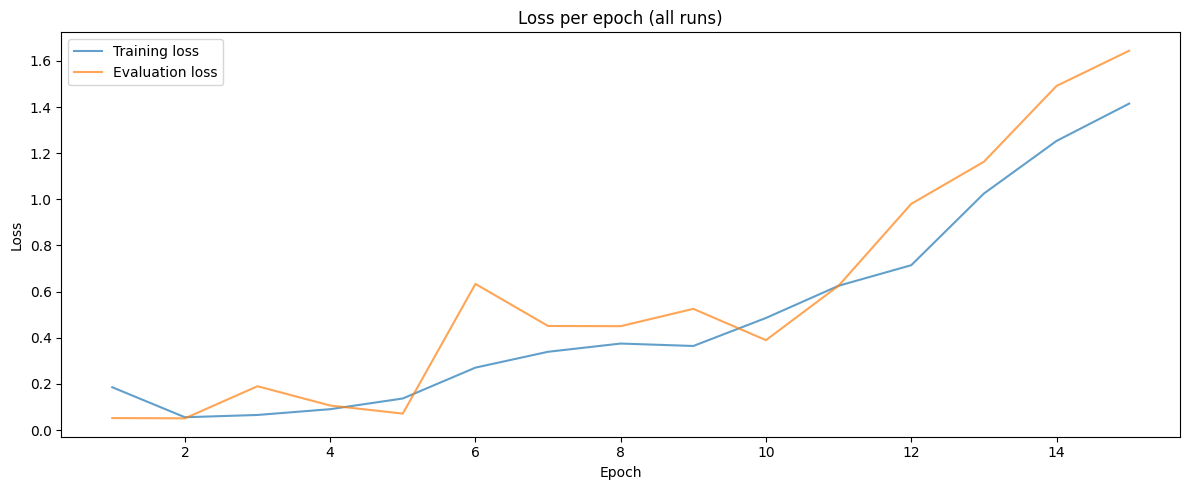

In [3]:
# Training loss vs evaluation loss (all runs combined)
fig, ax = plt.subplots(figsize=(12, 5))
epochs = range(1, len(all_training_loss) + 1)
ax.plot(epochs, all_training_loss, label="Training loss", alpha=0.7)
ax.plot(epochs, all_eval_loss, label="Evaluation loss", alpha=0.7)
for b in run_epoch_boundaries[1:]:
    ax.axvline(x=b + 1, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss per epoch (all runs)")
ax.legend()
plt.tight_layout()
plt.show()

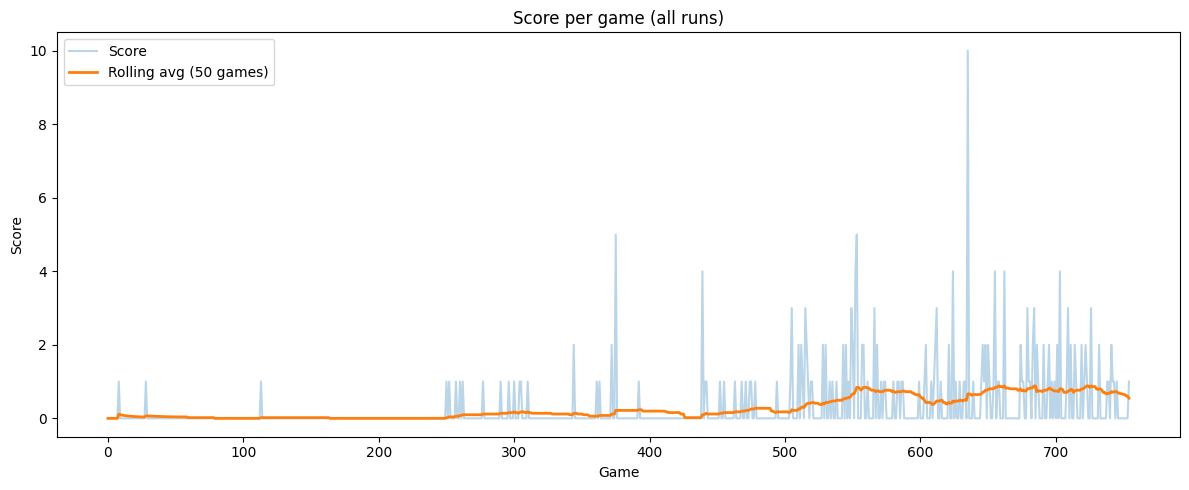

In [4]:
# Score per game with rolling average
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_scores, alpha=0.3, label="Score")
window = min(50, len(all_scores))
if window > 0:
    rolling = [sum(all_scores[max(0,i-window):i+1]) / len(all_scores[max(0,i-window):i+1]) for i in range(len(all_scores))]
    ax.plot(rolling, label=f"Rolling avg ({window} games)", linewidth=2)
for b in run_game_boundaries[1:]:
    ax.axvline(x=b, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Game")
ax.set_ylabel("Score")
ax.set_title("Score per game (all runs)")
ax.legend()
plt.tight_layout()
plt.show()

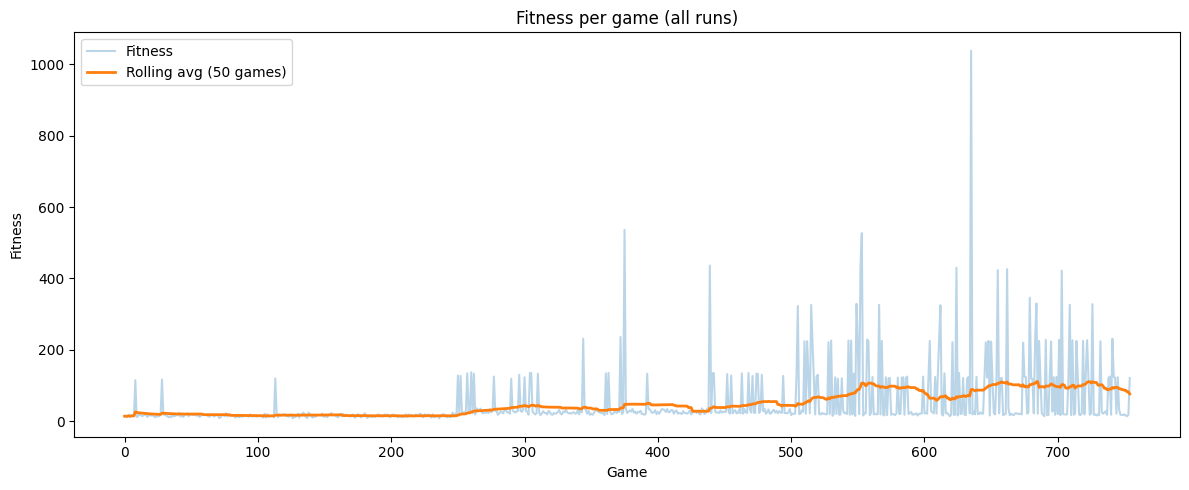

In [5]:
# Fitness per game with rolling average
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_fitnesses, alpha=0.3, label="Fitness")
if window > 0:
    rolling_f = [sum(all_fitnesses[max(0,i-window):i+1]) / len(all_fitnesses[max(0,i-window):i+1]) for i in range(len(all_fitnesses))]
    ax.plot(rolling_f, label=f"Rolling avg ({window} games)", linewidth=2)
for b in run_game_boundaries[1:]:
    ax.axvline(x=b, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Game")
ax.set_ylabel("Fitness")
ax.set_title("Fitness per game (all runs)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Summary stats per epoch (50 games each)
print(f"{'Epoch':>6} {'Train Loss':>12} {'Eval Loss':>12} {'Avg Score':>12} {'Avg Fitness':>12}")
print("-" * 58)
for i in range(len(all_training_loss)):
    epoch_scores = all_scores[i*50:(i+1)*50]
    epoch_fitnesses = all_fitnesses[i*50:(i+1)*50]
    avg_score = sum(epoch_scores) / len(epoch_scores) if epoch_scores else 0
    avg_fitness = sum(epoch_fitnesses) / len(epoch_fitnesses) if epoch_fitnesses else 0
    print(f"{i+1:>6} {all_training_loss[i]:>12.4f} {all_eval_loss[i]:>12.4f} {avg_score:>12.2f} {avg_fitness:>12.2f}")

 Epoch   Train Loss    Eval Loss    Avg Score  Avg Fitness
----------------------------------------------------------
     1       0.1855       0.0519         0.04        19.86
     2       0.0554       0.0506         0.00        15.50
     3       0.0653       0.1899         0.02        17.52
     4       0.0903       0.1062         0.00        15.18
     5       0.1367       0.0712         0.00        15.34
     6       0.2704       0.6333         0.16        42.80
     7       0.3392       0.4510         0.12        36.88
     8       0.3748       0.4502         0.20        45.98
     9       0.3643       0.5253         0.12        38.62
    10       0.4858       0.3896         0.18        44.92
    11       0.6254       0.6255         0.64        86.08
    12       0.7145       0.9805         0.60        81.32
    13       1.0251       1.1629         0.76        98.38
    14       1.2532       1.4916         0.76        98.12
    15       1.4150       1.6443         0.66        87.